# Dự án Machine Learning: Iris — Phân loại loài hoa Diên vĩ

**Bài toán:** Phân loại đa lớp (Multi-class Classification) — dự đoán loài hoa Iris (*setosa*, *versicolor*, *virginica*) dựa trên 4 số đo: chiều dài/rộng đài hoa (sepal) và cánh hoa (petal).

**Cách trình bày:** Notebook này áp dụng **quy trình 6 bước** cho một dự án Machine Learning được trình bày ở **Phần III — Projects**, sách *Machine Learning Mastery With Python* (Jason Brownlee). Đây cũng chính là bộ dữ liệu mà sách dùng làm ví dụ minh họa xuyên suốt ở **Chương 19 — "Your First Machine Learning Project in Python Step-By-Step"** (được sách gọi vui là *"Hello World" của Machine Learning*), nên notebook bám sát rất chặt cách trình bày gốc của sách:

1. **Prepare Problem** — Chuẩn bị bài toán (load thư viện, load dữ liệu)
2. **Summarize Data** — Tóm tắt dữ liệu (thống kê mô tả, trực quan hóa)
3. **Prepare Data** — Chuẩn bị dữ liệu (kiểm tra làm sạch, chọn đặc trưng, biến đổi dữ liệu)
4. **Evaluate Algorithms** — Đánh giá thuật toán (tách tập validation, spot-check nhiều mô hình, so sánh)
5. **Improve Accuracy** — Cải thiện độ chính xác (tuning tham số, ensemble)
6. **Finalize Model** — Hoàn thiện mô hình (dự đoán, lưu mô hình)

**Dữ liệu:** `iris.csv` — bộ dữ liệu Iris kinh điển của UCI Machine Learning Repository (Fisher, 1936), 150 mẫu, 4 thuộc tính số + 1 nhãn lớp, hoàn toàn không có giá trị thiếu.


## 1. Prepare Problem

### 1.a) Load libraries

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

RANDOM_STATE = 7


### 1.b) Load dataset

In [13]:
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
dataset = pd.read_csv(r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Iris\ex01_iris_classification\data\iris.csv', header=None, names=names)

print('Kích thước dữ liệu:', dataset.shape)
dataset.head()

Kích thước dữ liệu: (150, 5)


,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Summarize Data

### 2.a) Descriptive statistics

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [15]:
# Thống kê mô tả cho từng thuộc tính số
dataset.describe()

,sepal-length,sepal-width,petal-length,petal-width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
# Phân bố lớp (Class Distribution) — mỗi loài có bao nhiêu mẫu
print(dataset['class'].value_counts())
print(dataset['class'].value_counts(normalize=True))

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
class
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64


In [17]:
# Ma trận tương quan giữa các thuộc tính số
dataset.drop(columns=['class']).corr()

,sepal-length,sepal-width,petal-length,petal-width
sepal-length,1.000000,-0.109369,0.871754,0.817954
sepal-width,-0.109369,1.000000,-0.420516,-0.356544
petal-length,0.871754,-0.420516,1.000000,0.962757
petal-width,0.817954,-0.356544,0.962757,1.000000


### 2.b) Data visualizations

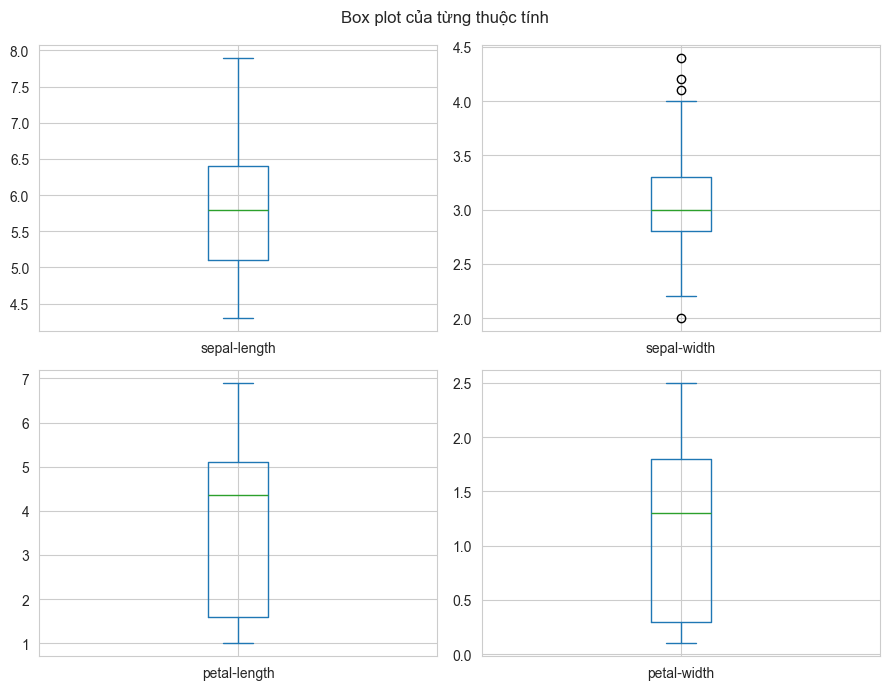

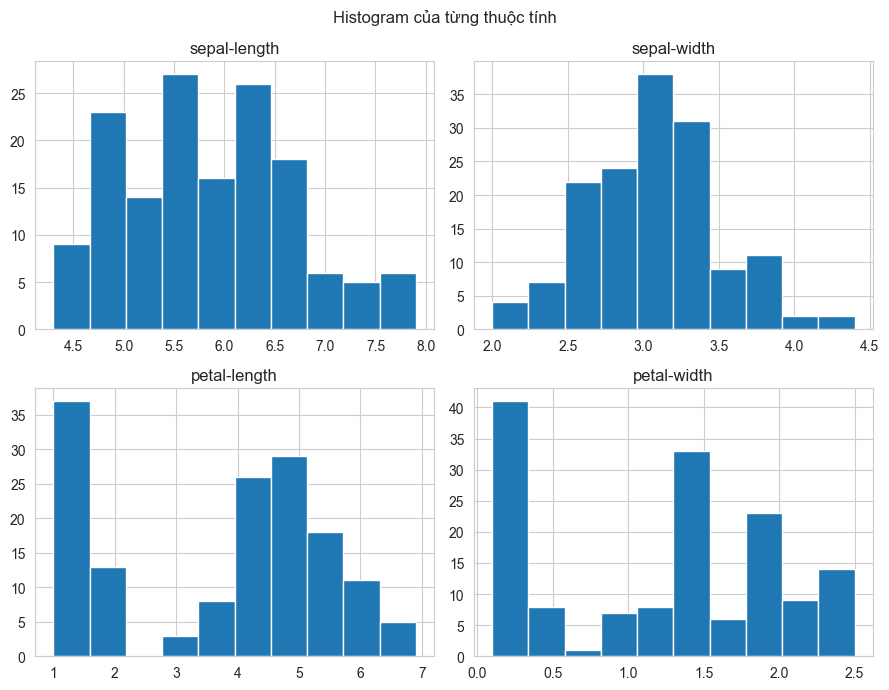

In [18]:
# Univariate plots — phân bố từng thuộc tính (box plot & histogram)
dataset.plot(kind='box', subplots=True, layout=(2, 2), sharex=False, sharey=False, figsize=(9, 7))
plt.suptitle('Box plot của từng thuộc tính')
plt.tight_layout()
plt.show()

dataset.hist(figsize=(9, 7))
plt.suptitle('Histogram của từng thuộc tính')
plt.tight_layout()
plt.show()

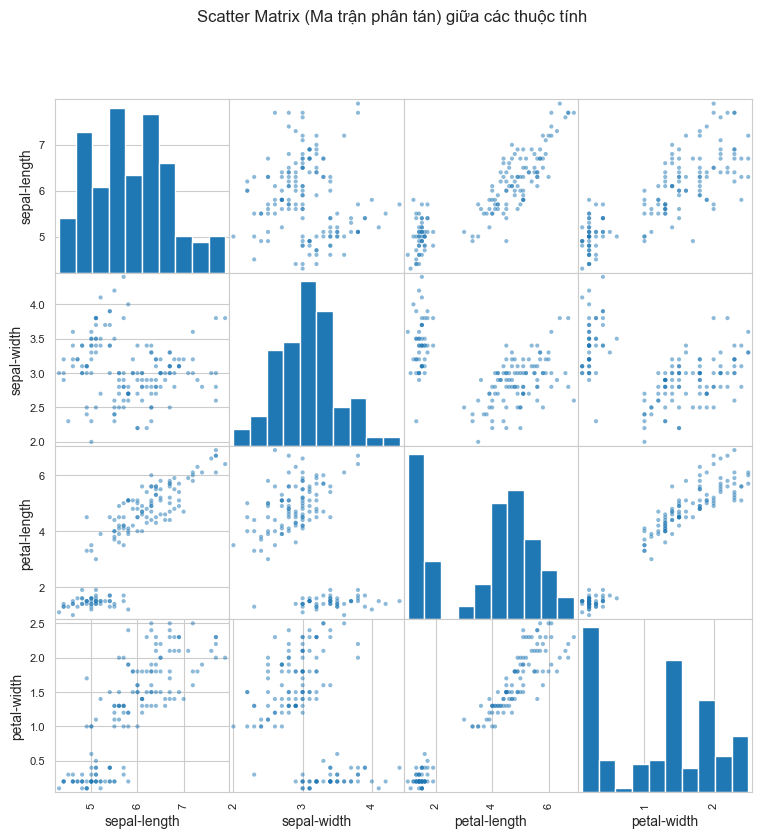

In [19]:
# Multivariate plots — scatter matrix để xem tương quan & khả năng phân tách giữa các loài
scatter_matrix(dataset.drop(columns=['class']), figsize=(9, 9), diagonal='hist')
plt.suptitle('Scatter Matrix (Ma trận phân tán) giữa các thuộc tính')
plt.show()

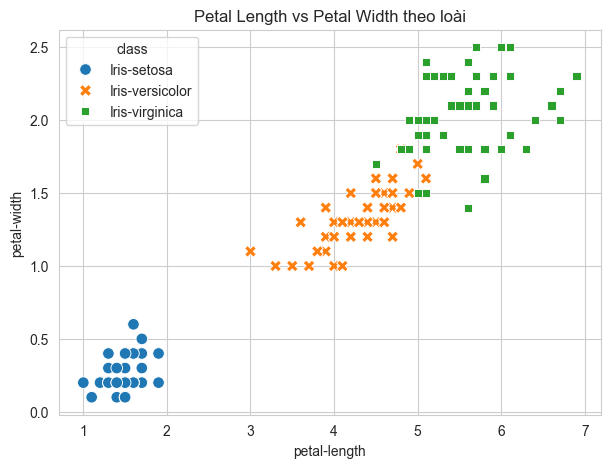

In [20]:
# Scatter plot petal-length vs petal-width, tô màu theo loài — cho thấy 2 thuộc tính cánh hoa
# phân tách 3 loài rất tốt
plt.figure(figsize=(7, 5))
sns.scatterplot(data=dataset, x='petal-length', y='petal-width', hue='class', style='class', s=70)
plt.title('Petal Length vs Petal Width theo loài')
plt.show()

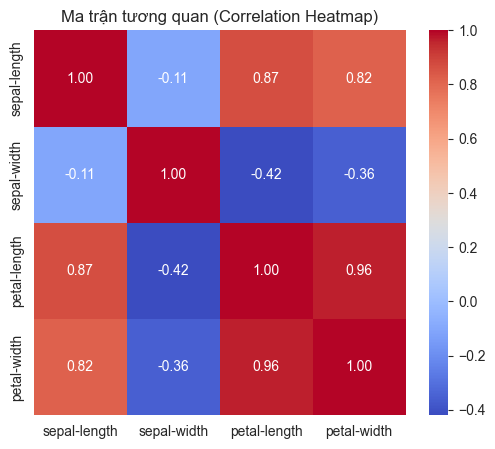

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(dataset.drop(columns=['class']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan (Correlation Heatmap)')
plt.show()

## 3. Prepare Data

### 3.a) Data Cleaning
Bộ dữ liệu Iris là dữ liệu chuẩn, sạch sẵn — không có giá trị thiếu, không có bản ghi trùng cần loại bỏ (kiểm tra lại dưới đây).

In [22]:
print('Số giá trị thiếu:')
print(dataset.isnull().sum())
print('\nSố bản ghi trùng lặp:', dataset.duplicated().sum())

Số giá trị thiếu:
sepal-length    0
sepal-width     0
petal-length    0
petal-width     0
class           0
dtype: int64

Số bản ghi trùng lặp: 3


### 3.b) Feature Selection
Cả 4 thuộc tính (sepal-length, sepal-width, petal-length, petal-width) đều có ý nghĩa sinh học và tương quan tốt với nhãn (đặc biệt petal-length/petal-width, thấy rõ ở biểu đồ trên) — giữ nguyên toàn bộ, không loại bỏ đặc trưng nào.

### 3.c) Data Transforms
Mã hóa nhãn lớp (`LabelEncoder`) và tách features/target. Việc chuẩn hóa (`StandardScaler`) được áp dụng vì có thuật toán nhạy về khoảng cách/khoảng giá trị (KNN, SVM).

In [23]:
le = LabelEncoder()
X = dataset.drop(columns=['class']).values
y = le.fit_transform(dataset['class'].values)

print('Các lớp:', list(le.classes_), '-> mã hóa thành', list(range(len(le.classes_))))

# Tách tập validation (giống 'Validation Dataset' trong sách, tỉ lệ 80/20)
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

print('X_train:', X_train.shape, ' X_validation:', X_validation.shape)

Các lớp: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'] -> mã hóa thành [0, 1, 2]
X_train: (120, 4)  X_validation: (30, 4)


## 4. Evaluate Algorithms

### 4.a) Split-out validation dataset
Đã thực hiện ở bước 3.c (tỉ lệ 80/20, phân tầng theo lớp).

### 4.b) Test options and evaluation metric
Dùng **Stratified 10-fold Cross Validation** trên tập train, độ đo **Accuracy** — giống hệt cách sách thực hiện ở Chương 19 (3 lớp cân bằng, mỗi lớp 50 mẫu).

### 4.c) Spot Check Algorithms
Đánh giá 6 thuật toán — đúng danh sách sách đề xuất: LR, LDA (tuyến tính) và KNN, CART, NB, SVM (phi tuyến).

In [24]:
seed = RANDOM_STATE
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

models = []
models.append(('LR', LogisticRegression(max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

results = []
names_list = []
print(f"{'Model':6s}  {'Mean Accuracy':>13s}  {'Std':>8s}")
for name, model in models:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names_list.append(name)
    print(f'{name:6s}  {cv_results.mean():13.4f}  {cv_results.std():8.4f}')

Model   Mean Accuracy       Std
LR             0.9417    0.0534
LDA            0.9750    0.0382
KNN            0.9417    0.0651
CART           0.9333    0.0500
NB             0.9417    0.0534
SVM            0.9417    0.0534


### 4.d) Compare Algorithms

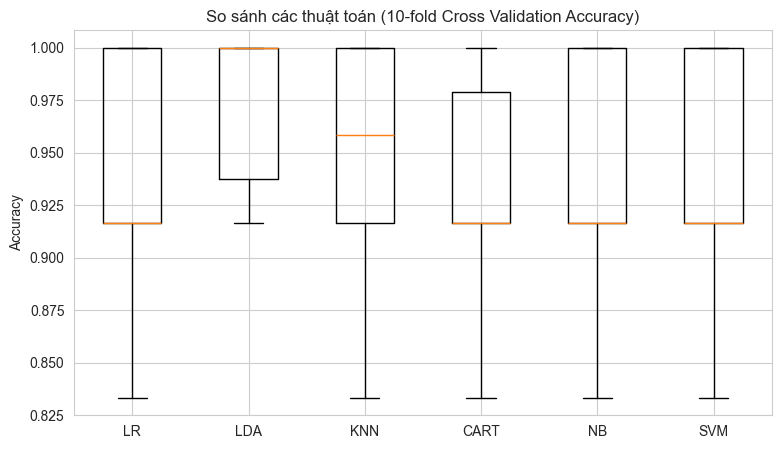

In [25]:
plt.figure(figsize=(9, 5))
plt.boxplot(results, labels=names_list)
plt.title('So sánh các thuật toán (10-fold Cross Validation Accuracy)')
plt.ylabel('Accuracy')
plt.show()

Giống nhận xét trong sách: vì Iris là bài toán khá "dễ" (các lớp gần như phân tách tuyến tính), nhiều mô hình đạt độ chính xác rất cao (thường trên 95%) và các box plot bị dồn lên sát đỉnh — khác hẳn với Titanic (bài toán khó và nhiễu hơn nhiều).

## 5. Improve Accuracy

Vì các mô hình đã đạt độ chính xác rất cao ngay từ bước spot-check, việc tuning ở đây mang tính minh họa quy trình hơn là cải thiện đáng kể kết quả.

### 5.a) Algorithm Tuning
Tinh chỉnh **KNN** (số hàng xóm) và **SVM** (C, gamma) bằng Grid Search.

In [26]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=kfold, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
print('KNN - Best score :', grid_knn.best_score_)
print('KNN - Best params:', grid_knn.best_params_)

KNN - Best score : 0.9583333333333333
KNN - Best params: {'n_neighbors': 9}


In [27]:
param_grid_svm = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}
grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=kfold, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train)
print('SVM - Best score :', grid_svm.best_score_)
print('SVM - Best params:', grid_svm.best_params_)

SVM - Best score : 0.975
SVM - Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


### 5.b) Ensembles
So sánh thêm **Random Forest** và một **Voting Classifier** kết hợp các mô hình đã tinh chỉnh.

In [28]:
ensembles = []
ensembles.append(('RF', RandomForestClassifier(random_state=seed)))
ensembles.append(('KNN-tuned', grid_knn.best_estimator_))
ensembles.append(('SVM-tuned', grid_svm.best_estimator_))

ens_results = []
ens_names = []
for name, model in ensembles:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    ens_results.append(cv_results)
    ens_names.append(name)
    print(f'{name:10s}  {cv_results.mean():.4f}  ({cv_results.std():.4f})')

voting_clf = VotingClassifier(estimators=[
    ('knn', grid_knn.best_estimator_),
    ('svm', grid_svm.best_estimator_),
    ('lda', LinearDiscriminantAnalysis())
], voting='soft')

voting_cv = cross_val_score(voting_clf, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f'{"Voting":10s}  {voting_cv.mean():.4f}  ({voting_cv.std():.4f})')

RF          0.9333  (0.0624)
KNN-tuned   0.9583  (0.0417)
SVM-tuned   0.9750  (0.0382)
Voting      0.9667  (0.0408)


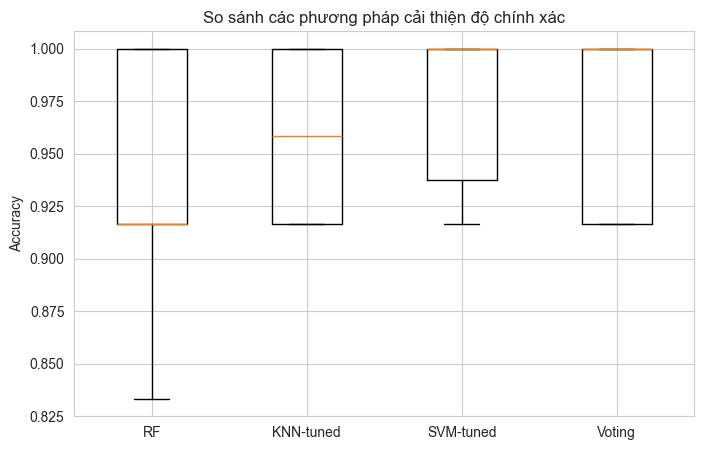

In [29]:
plt.figure(figsize=(8, 5))
all_results = ens_results + [voting_cv]
all_names = ens_names + ['Voting']
plt.boxplot(all_results, labels=all_names)
plt.title('So sánh các phương pháp cải thiện độ chính xác')
plt.ylabel('Accuracy')
plt.show()

## 6. Finalize Model

### 6.a) Predictions on validation dataset
Chọn mô hình tốt nhất theo cross-validation và đánh giá trên tập validation — dữ liệu hoàn toàn chưa từng dùng để huấn luyện hay tuning.

In [30]:
candidates = {
    'KNN-tuned': grid_knn.best_estimator_,
    'SVM-tuned': grid_svm.best_estimator_,
    'Voting': voting_clf
}

best_name, best_score = None, -1
for name, model in candidates.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_validation_scaled)
    acc = accuracy_score(y_validation, preds)
    print(f'{name:10s} - Validation Accuracy: {acc:.4f}')
    if acc > best_score:
        best_name, best_score, best_preds = name, acc, preds

print(f'\n=> Mô hình được chọn: {best_name} (Validation Accuracy = {best_score:.4f})')
print('\nClassification report:')
print(classification_report(y_validation, best_preds, target_names=le.classes_))

KNN-tuned  - Validation Accuracy: 0.9667
SVM-tuned  - Validation Accuracy: 1.0000
Voting     - Validation Accuracy: 1.0000

=> Mô hình được chọn: SVM-tuned (Validation Accuracy = 1.0000)

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



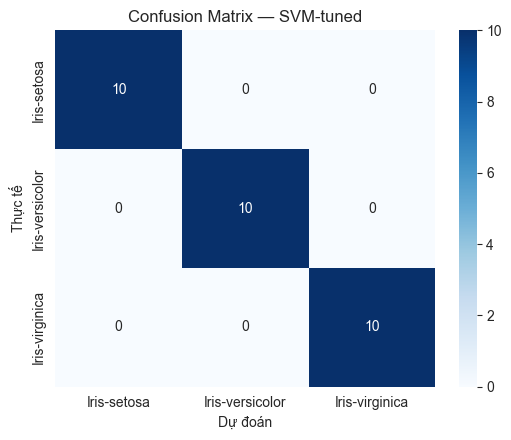

In [31]:
cm = confusion_matrix(y_validation, best_preds)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

### 6.b) Create standalone model on entire dataset

In [32]:
final_model = candidates[best_name]

final_scaler = StandardScaler().fit(X)
X_full_scaled = final_scaler.transform(X)

final_model.fit(X_full_scaled, y)
print('Đã huấn luyện lại mô hình cuối cùng trên toàn bộ dữ liệu (150 mẫu).')

Đã huấn luyện lại mô hình cuối cùng trên toàn bộ dữ liệu (150 mẫu).


### 6.c) Save model for later use

In [33]:
with open('iris_final_model.pkl', 'wb') as f:
    pickle.dump({
        'model': final_model,
        'scaler': final_scaler,
        'label_encoder': le,
        'columns': names[:-1]
    }, f)
print('Đã lưu mô hình vào iris_final_model.pkl')

Đã lưu mô hình vào iris_final_model.pkl


#### Thử dự đoán nhanh với mẫu mới (minh họa cách dùng mô hình đã lưu)

In [34]:
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2], [6.7, 3.1, 4.7, 1.5], [6.5, 3.0, 5.8, 2.2]],
                      columns=names[:-1])
sample_scaled = final_scaler.transform(sample.values)
sample_pred = final_model.predict(sample_scaled)
print(pd.concat([sample, pd.Series(le.inverse_transform(sample_pred), name='predicted_class')], axis=1))

   sepal-length  sepal-width  petal-length  petal-width  predicted_class
0           5.1          3.5           1.4          0.2      Iris-setosa
1           6.7          3.1           4.7          1.5  Iris-versicolor
2           6.5          3.0           5.8          2.2   Iris-virginica


## Tổng kết

- Đã đi qua đầy đủ **6 bước** của quy trình dự án ML theo sách *Machine Learning Mastery With Python*, bám sát ví dụ gốc ở **Chương 19** (bài toán Iris — bài "Hello World" của sách).
- Iris là bài toán **phân loại đa lớp (3 lớp)**, dữ liệu sạch, các lớp gần như phân tách tuyến tính (đặc biệt qua petal-length/petal-width) → hầu hết mô hình đạt độ chính xác rất cao (thường ≥ 95%) ngay từ bước spot-check.
- So với **Titanic** (bài toán nhị phân, dữ liệu thực tế nhiều nhiễu, cần xử lý missing/feature engineering nhiều), Iris minh họa rõ sự khác biệt: ở đây bước "Improve Accuracy" mang giá trị **thực hành quy trình** hơn là cải thiện kết quả đáng kể.
- Mô hình cuối cùng (được chọn tự động ở bước 6.a) đã được huấn luyện lại trên **toàn bộ** 150 mẫu và lưu vào `iris_final_model.pkl` để tái sử dụng.
